# AMS · Análise exploratória dos dados de manutenção

**Disciplina 1 — Programação Python para IA · CEAI/UTFPR**

Dataset: *AI4I 2020 Predictive Maintenance Dataset* (UCI, ID 601) — leituras de
sensores de máquinas-ferramenta e seus modos de falha.

**A regra da disciplina neste notebook:** nenhum gráfico existe por si só. Cada
seção abaixo é uma *pergunta*, respondida com código, um gráfico e **uma frase de
conclusão em negrito**. Gráfico sem pergunta é decoração.

O carregamento usa o pacote `ams`: se o dataset completo (`data/raw/`) não foi
baixado, ele cai automaticamente na amostra versionada (`data/amostra/`, 200
linhas) — o notebook roda em qualquer máquina, com ou sem internet.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

from ams import analise
from ams.dados import carregar, preparar

sns.set_theme(style="whitegrid")
dataset = carregar()
df = preparar(dataset.quadro)

print(f"fonte dos dados: {dataset.fonte}")
print(f"dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head(3)

fonte dos dados: raw/ai4i2020.csv (10000 linhas)
dimensões: 10000 linhas x 17 colunas


,udi,product_id,tipo,temperatura_ar,temperatura_processo,rotacao,torque,desgaste,falha,twf,hdf,pwf,osf,rnf,delta_temperatura,potencia_kw,algum_modo
0,1,M14860,M,298.1,308.6,1551,42.8,0,False,False,False,False,False,False,10.5,6.951591,False
1,2,L47181,L,298.2,308.7,1408,46.3,3,False,False,False,False,False,False,10.5,6.826723,False
2,3,L47182,L,298.1,308.5,1498,49.4,5,False,False,False,False,False,False,10.4,7.749388,False


---

## Pergunta 1 — Qual a taxa de falha geral e por tipo de produto?

As máquinas são classificadas em L (baixa qualidade), M (média) e H (alta).
Suspeita do domínio: quanto mais simples a máquina, mais ela falha.

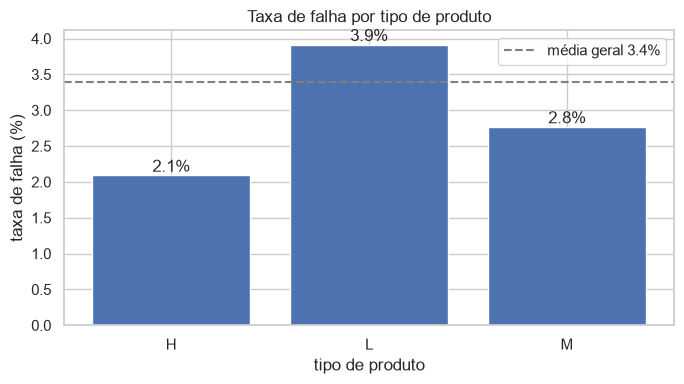

taxa geral: 3.39%  |  por tipo: {'H': 2.09, 'L': 3.92, 'M': 2.77}


In [2]:
fig, eixo = plt.subplots(figsize=(7, 4))
taxas = analise.taxa_falha_por_tipo(df)
geral = analise.taxa_falha_geral(df) * 100
barras = eixo.bar(taxas.index.astype(str), taxas.values)
eixo.axhline(geral, color="gray", linestyle="--", label=f"média geral {geral:.1f}%")
eixo.set_xlabel("tipo de produto")
eixo.set_ylabel("taxa de falha (%)")
eixo.set_title("Taxa de falha por tipo de produto")
eixo.legend()
for barra in barras:
    x = barra.get_x() + barra.get_width() / 2
    eixo.annotate(f"{barra.get_height():.1f}%", (x, barra.get_height()),
                  ha="center", va="bottom")
plt.tight_layout()
plt.show()

print(f"taxa geral: {geral:.2f}%  |  por tipo: {taxas.round(2).to_dict()}")

**Conclusão:** a falha é rara (na casa de 3–4%) e cresce conforme a qualidade
cai — L falha mais que M, que falha mais que H. Em consequência, um classificador
que responda sempre "não vai falhar" já acerta ~96%: **acurácia alta aqui é fácil
e enganosa**, e é por isso que as próximas disciplinas tratam de baseline e de
outras métricas antes de qualquer modelo.

---

## Pergunta 2 — Como o desgaste da ferramenta se distribui entre máquinas que falharam e que não falharam?

O desgaste acumulado (`desgaste`, em minutos) é a variável que a intuição aponta
como a mais óbvia candidata a preditor de falha.

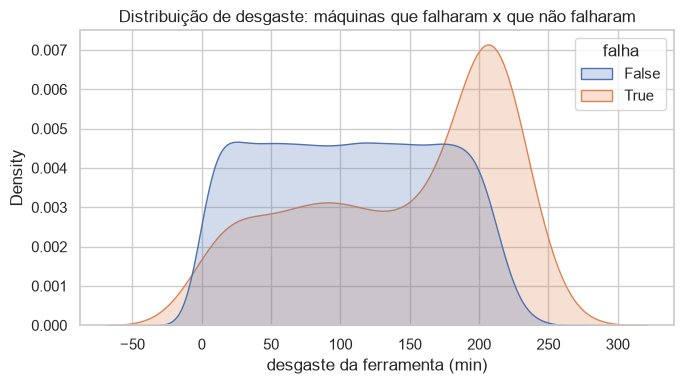

,count,mean,std,min,25%,50%,75%,max
falha,,,,,,,,
False,9661.0,106.7,62.9,0.0,52.0,107.0,160.0,246.0
True,339.0,143.8,72.8,0.0,84.5,165.0,207.5,253.0


In [3]:
fig, eixo = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=df, x="desgaste", hue="falha", common_norm=False, fill=True, ax=eixo)
eixo.set_xlabel("desgaste da ferramenta (min)")
eixo.set_title("Distribuição de desgaste: máquinas que falharam x que não falharam")
plt.tight_layout()
plt.show()

df.groupby("falha")["desgaste"].describe().round(1)

**Conclusão:** as máquinas que falharam se concentram em desgaste alto (acima
de ~200 min), enquanto as sem falha se espalham por toda a faixa — o desgaste
carrega sinal real, mas as distribuições **se sobrepõem**: desgaste alto não
garante falha, e existe falha com desgaste baixo. Uma única variável não
resolve.

---

## Pergunta 3 — Existe relação entre torque e rotação? O que a nuvem de pontos mostra sobre os modos de falha?

Física da máquina: potência aproximadamente constante ⇒ torque e rotação são
inversamente relacionados.

correlação torque x rotação: -0.88


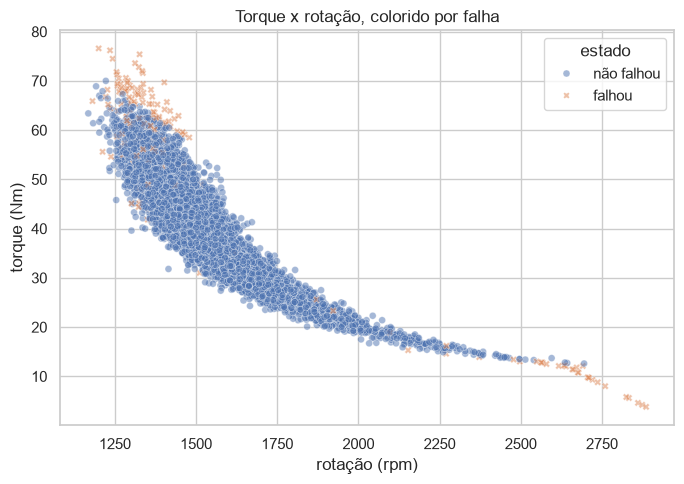

In [4]:
correlacao = analise.correlacao_torque_rotacao(df)
print(f"correlação torque x rotação: {correlacao:.2f}")

fig, eixo = plt.subplots(figsize=(7, 5))
falha = df["falha"].map({True: "falhou", False: "não falhou"})
sns.scatterplot(data=df.assign(estado=falha), x="rotacao", y="torque",
                hue="estado", style="estado", alpha=0.5, s=25, ax=eixo)
eixo.set_xlabel("rotação (rpm)")
eixo.set_ylabel("torque (Nm)")
eixo.set_title("Torque x rotação, colorido por falha")
plt.tight_layout()
plt.show()

**Conclusão:** a correlação fortemente negativa confirma a física — a
potência é aproximadamente constante. E a nuvem mostra que as falhas se aglomeram
nos **cantos extremos** da faixa operacional (rotação baixa com torque alto, e o
oposto): quem sai do miolo da curva potência-constante corre risco. O modo PWF
(falha de potência) é exatamente a formalização disso.

---

## Pergunta 4 — Qual a diferença entre temperatura do processo e do ar, e ela prediz falha?

A coluna derivada `delta_temperatura` (processo − ar) mede quanto a máquina está
aquecendo acima do ambiente.

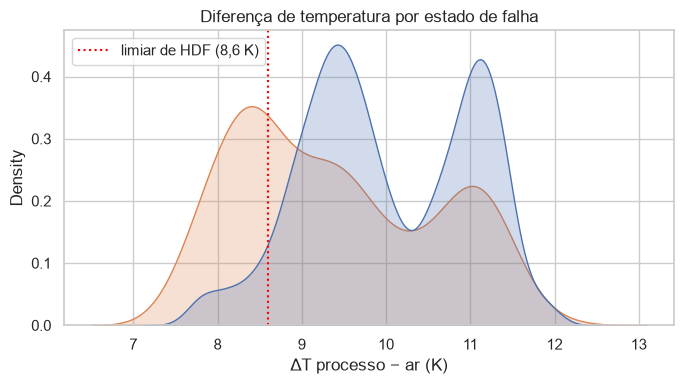

falhas com ΔT < 8,6 K: 126
total com ΔT < 8,6 K: 720


In [5]:
fig, eixo = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=df, x="delta_temperatura", hue="falha", common_norm=False, fill=True, ax=eixo)
eixo.axvline(8.6, color="red", linestyle=":", label="limiar de HDF (8,6 K)")
eixo.set_xlabel("ΔT processo − ar (K)")
eixo.set_title("Diferença de temperatura por estado de falha")
eixo.legend()
plt.tight_layout()
plt.show()

print(f"falhas com ΔT < 8,6 K: {(df['falha'] & (df['delta_temperatura'] < 8.6)).sum()}")
print(f"total com ΔT < 8,6 K: {(df['delta_temperatura'] < 8.6).sum()}")

**Conclusão:** a diferença de temperatura anda na faixa ~8,6–11,5 K e, sozinha,
quase não separa falha de não-falha — a exceção é o limiar de 8,6 K, que define o
modo HDF: praticamente toda máquina abaixo dele com falha é um caso HDF. **A
variável não é um preditor geral de falha, mas é o gatilho de um modo
específico** — cada modo de falha tem sua própria física.

---

## Pergunta 5 — Quais modos de falha são mais frequentes e eles se sobrepõem?

Uma máquina pode ter mais de um modo marcado ao mesmo tempo.

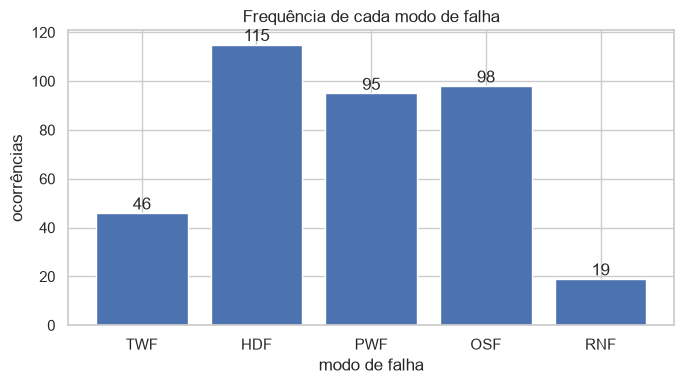

registros com mais de um modo ao mesmo tempo: 24


In [6]:
modos = analise.frequencia_de_modos(df)
sobreposicao = df[["twf", "hdf", "pwf", "osf", "rnf"]].sum(axis=1)
mais_de_um = int((sobreposicao >= 2).sum())

fig, eixo = plt.subplots(figsize=(7, 4))
eixo.bar(modos.index.str.upper(), modos.values, color="#4c72b0")
eixo.set_xlabel("modo de falha")
eixo.set_ylabel("ocorrências")
eixo.set_title("Frequência de cada modo de falha")
for i, valor in enumerate(modos.values):
    eixo.annotate(str(int(valor)), (i, valor), ha="center", va="bottom")
plt.tight_layout()
plt.show()

print(f"registros com mais de um modo ao mesmo tempo: {mais_de_um}")

**Conclusão:** os cinco modos têm frequências da mesma ordem de grandeza
(nenhum domina) e existem máquinas com **dois modos simultâneos** — a falha não é
um evento único, é a soma de mecanismos independentes. Para o agente, isso
importa: a saída útil não é só "falha sim/não", mas *qual* mecanismo está agindo.

---

## Pergunta 6 — Há registros com falha indicada mas nenhum modo marcado?

Esta pergunta é sobre **qualidade de dados**, não sobre física. Se o indicador
geral e os modos discordam, um deles está errado — e o analista precisa saber
antes de treinar qualquer coisa.

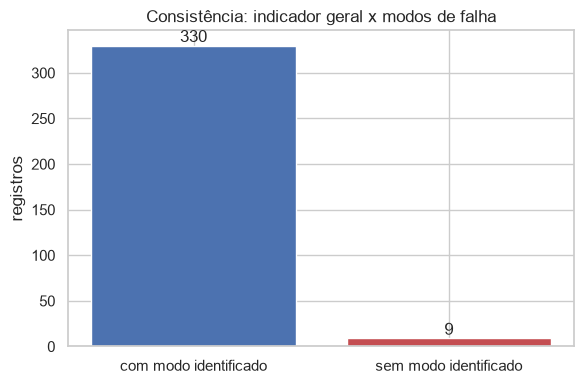

,udi,product_id,tipo,temperatura_ar,temperatura_processo,rotacao,torque,desgaste,falha,twf,hdf,pwf,osf,rnf,delta_temperatura,potencia_kw,algum_modo
1437,1438,H30851,H,298.8,309.9,1439,45.2,40,True,False,False,False,False,False,11.1,6.811266,False
2749,2750,M17609,M,299.7,309.2,1685,28.9,179,True,False,False,False,False,False,9.5,5.099486,False
4044,4045,M18904,M,301.9,310.9,1419,47.7,20,True,False,False,False,False,False,9.0,7.088093,False
4684,4685,M19544,M,303.6,311.8,1421,44.8,101,True,False,False,False,False,False,8.2,6.666543,False
5536,5537,M20396,M,302.3,311.8,1363,54.0,119,True,False,False,False,False,False,9.5,7.707583,False


In [7]:
sem_modo = analise.falhas_sem_modo(df)
contagem = [int(df["falha"].sum()) - len(sem_modo), len(sem_modo)]

fig, eixo = plt.subplots(figsize=(6, 4))
eixo.bar(["com modo identificado", "sem modo identificado"], contagem,
         color=["#4c72b0", "#c44e52"])
eixo.set_ylabel("registros")
eixo.set_title("Consistência: indicador geral x modos de falha")
for i, valor in enumerate(contagem):
    eixo.annotate(str(valor), (i, valor), ha="center", va="bottom")
plt.tight_layout()
plt.show()

sem_modo.head(5)

**Conclusão:** sim — existem registros com `Machine failure = 1` e nenhum dos
cinco modos marcado (no dataset completo são 27 casos). **Dados reais vêm
inconsistentes, e ninguém avisa**; quem não pergunta isso descobre depois, quando
o modelo treinado "misteriosamente" erra. A limpeza e a decisão sobre esses casos
entram na disciplina de dados (D7).

---

## Pergunta 7 — Qual seria a acurácia de uma regra simples do tipo "desgaste > X"?

Antes de qualquer aprendizado de máquina, o mínimo honesto é saber o que uma
regra de um limiar consegue.

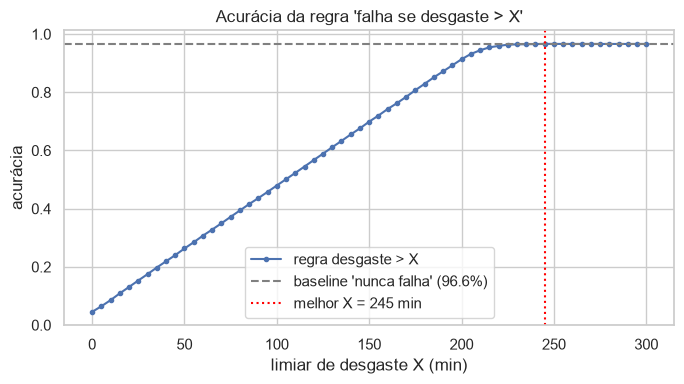

melhor limiar: 245 min → acurácia 96.64%
baseline 'nunca falha': 96.61%


In [8]:
limiares = range(0, 301, 5)
acuracias = [analise.acuracia_regra_desgaste(df, limite) for limite in limiares]
melhor_limiar, melhor_acuracia = analise.melhor_limiar_desgaste(df)
baseline = 1 - analise.taxa_falha_geral(df)

fig, eixo = plt.subplots(figsize=(7, 4))
eixo.plot(list(limiares), acuracias, marker=".", label="regra desgaste > X")
rotulo = f"baseline 'nunca falha' ({baseline:.1%})"
eixo.axhline(baseline, color="gray", linestyle="--", label=rotulo)
eixo.axvline(melhor_limiar, color="red", linestyle=":", label=f"melhor X = {melhor_limiar} min")
eixo.set_xlabel("limiar de desgaste X (min)")
eixo.set_ylabel("acurácia")
eixo.set_title("Acurácia da regra 'falha se desgaste > X'")
eixo.legend()
plt.tight_layout()
plt.show()

print(f"melhor limiar: {melhor_limiar} min → acurácia {melhor_acuracia:.2%}")
print(f"baseline 'nunca falha': {baseline:.2%}")

**Conclusão:** a melhor regra de um único limiar fica a poucos pontos do
baseline "nunca falha" — ou seja, quase todo o ganho vem de capturar uma
minoria pequena de casos. **É contra esse número que um modelo de ML terá de
competir na D5**; e é por isso que acurácia sozinha não diz se o modelo presta.

---

## Pergunta 8 — O que este dataset **não** consegue responder sobre segurança do trabalho?

O objetivo do AMS é emitir checklist de segurança. O que falta aqui para isso?
Olhamos o que as variáveis cobrem — e o que fica de fora.

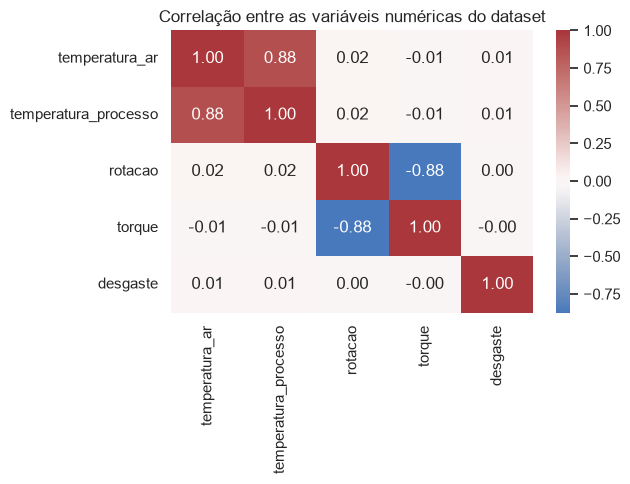

colunas disponíveis: ['udi', 'product_id', 'tipo', 'temperatura_ar', 'temperatura_processo', 'rotacao', 'torque', 'desgaste', 'falha', 'twf', 'hdf', 'pwf', 'osf', 'rnf']


In [9]:
numericas = ["temperatura_ar", "temperatura_processo", "rotacao", "torque", "desgaste"]
correlacao_matriz = df[numericas].corr()

fig, eixo = plt.subplots(figsize=(6.5, 5))
sns.heatmap(correlacao_matriz, annot=True, fmt=".2f", cmap="vlag", center=0, ax=eixo)
eixo.set_title("Correlação entre as variáveis numéricas do dataset")
plt.tight_layout()
plt.show()

print("colunas disponíveis:", list(dataset.quadro.columns))

**Conclusão:** tudo aqui é sensor físico de processo — nada fala de
*procedimento*, *norma aplicável*, *histórico de intervenções* ou *condição da
equipe*, que é de onde vem uma decisão de segurança. **A lacuna é estrutural, não
de modelagem** — e é exatamente por isso que o curso acrescenta um corpus
documental (as NRs na D7) e recuperação (RAG na D9): a resposta de segurança
vive em texto, não em sensor.

---

## Síntese para o projeto

1. Falha é evento raro e multicausal — cinco modos, cada qual com sua física.
2. Sensores carregam sinal, mas sobreposições grandes: sem modelo único óbvio.
3. Dados têm inconsistência real (falha sem modo) — qualidade é etapa própria.
4. A decisão de segurança precisa de conhecimento documental que não está aqui.

Na sequência do curso: a D2 transforma estas conclusões na especificação formal
do agente (`agent-spec.md`); a D5 tenta bater a regra do desgaste; a D7 resolve a
limpeza e o corpus de normas.

---

## O que meu agente precisaria saber para decidir isso?

Esta é a seção que a D2 abre no primeiro dia: ela vira o `agent-spec.md`.
Cada item nasce de uma conclusão acima — nada aqui é wishful thinking.

1. **O tipo de produto na ordem.** A mesma rotação é normal num produto e
   suspeita noutro (as falhas se aglomeram nos cantos da curva
   potência-constante). Sem saber qual produto está em usinagem, o agente
   não sabe onde fica o "miolo" seguro.
2. **Os limiares físicos de cada modo de falha.** A diferença de temperatura
   só decide HDF (limiar 8,6 K); o desgaste carrega sinal mas sobrepõe
   distribuições. Decidir "qual mecanismo está agindo" exige os limiares de
   TWF/HDF/PWF/OSF — que não vêm nos sensores, vêm da norma do fabricante.
3. **O custo de cada erro.** A falha é rara (~3–4%) e multicausal; um
   classificador que sempre diz "não falha" já acerta ~96%. Só existe
   decisão racional comparando a probabilidade ao **custo** de parar a
   máquina sem necessidade versus não parar quando devia.
4. **O histórico da máquina específica.** O dataset é anônimo quanto a
   máquinas cronicamente piores; a taxa global esconde população desigual.
5. **Como tratar os 27 registros inconsistentes** (falha marcada sem nenhum
   dos cinco modos): o agente precisa de uma política explícita — confiar no
   rótulo, confiar nos modos, ou pedir inspeção.

O que os dados **não** dizem — procedimento, norma aplicável, histórico de
intervenções, condição da equipe — é exatamente o que o corpus textual da
disciplina acrescenta ao projeto.
